In [1]:
from utilities.data_loader import load_data

train_prices, train_dates, test_prices, test_dates = load_data("./data/BTC-Daily.csv")

We are going to determine a naive solution of Buy and Hold as benchmark for performance later

In [2]:
from optimizer.evaluator import execute_buy, execute_sell
_, btc_held = execute_buy(1000, test_prices[0], 0.03)
BUY_AND_HOLD_BENCHMARK, _ = execute_sell(btc_held, test_prices[-1], 0.03)
print(BUY_AND_HOLD_BENCHMARK)

5660.26318654683


In [3]:
import pandas as pd

fixed_results = pd.read_csv("results/fixed_runs.csv")
random_results = pd.read_csv("results/random_runs.csv")

In [4]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['start_mode', 'algo', 'strategy'])['test_final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)
display(stats.map(fmt))

count        mean         std  \
start_mode algo strategy                                           
fixed      abo  ema_independent  50.0000  1,343.3436    556.8771   
                ema_shared       50.0000  1,767.2350  1,381.0842   
                lma              50.0000    695.7492    186.7396   
                sma              50.0000  1,168.8281     28.6966   
                weighted         50.0000  4,443.1968  1,024.0173   
           aos  ema_independent  50.0000  1,124.4190    678.4860   
                ema_shared       50.0000  1,911.4673  1,561.8691   
                lma              50.0000    755.2026    189.0924   
                sma              50.0000  1,165.2870     13.4210   
                weighted         50.0000  4,673.7811    710.7668   
           gps  ema_independent  50.0000  2,708.3422  1,760.8594   
                ema_shared       50.0000  2,004.7037  2,199.4984   
                lma              50.0000    876.9529    221.8494   
                sma              50.0000  1,098.2348    253.5290   
                weighted         50.0000  2,359.9231  1,622.8533   
           mrfo ema_independent  50.0000  1,000.0000   0.000e+00   
                ema_shared       50.0000  2,011.2933  1,862.1564   
                lma              50.0000    732.7786    203.2391   
                sma              50.0000  1,180.2757   0.000e+00   
                weighted         50.0000  4,506.1517    966.6684   
           pso  ema_independent  50.0000  2,942.8328  1,539.3752   
                ema_shared       50.0000  2,228.9121  1,841.0280   
                lma              50.0000    626.3646    167.5094   
                sma              50.0000  1,134.9269    116.2190   
                weighted         50.0000  4,604.8972    901.0757   
           sos  ema_independent  50.0000  3,786.0687  1,403.8543   
                ema_shared       50.0000  2,197.2536  2,201.6755   
                lma              50.0000    907.9777   0.000e+00   
                sma              50.0000  1,180.2757   0.000e+00   
                weighted         50.0000  4,820.7168    519.0279   
random     abo  ema_independent  50.0000  1,568.5077    978.7515   
                ema_shared       50.0000  2,040.7577  1,861.5472   
                lma              50.0000    741.6967    185.4224   
                sma              50.0000  1,171.1792     13.8903   
                weighted         50.0000  4,464.3833  1,227.4913   
           aos  ema_independent  50.0000  1,035.3013    185.8953   
                ema_shared       50.0000  1,918.3623  1,756.9901   
                lma              50.0000    842.8023    145.9989   
                sma              50.0000  1,165.2870     13.4210   
                weighted         50.0000  4,538.8629    940.2149   
           gps  ema_independent  50.0000  2,559.4843  1,658.7433   
                ema_shared       50.0000  1,935.5615  2,196.9898   
                lma              50.0000    935.4467    212.1380   
                sma              50.0000  1,062.7538    244.3775   
                weighted         50.0000  2,244.3741  1,694.3699   
           mrfo ema_independent  50.0000  1,000.0000   0.000e+00   
                ema_shared       50.0000  1,726.0392  1,682.6317   
                lma              50.0000    785.5819    190.5563   
                sma              50.0000  1,180.2757   0.000e+00   
                weighted         50.0000  4,634.4553    993.7617   
           pso  ema_independent  50.0000  3,633.6430  1,358.1823   
                ema_shared       50.0000  2,301.1660  2,152.8926   
                lma              50.0000    692.5486    177.4054   
                sma              50.0000  1,090.6623    185.0190   
                weighted         50.0000  4,415.3144  1,078.6118   
           sos  ema_independent  50.0000  3,826.7613  1,359.3697   
                ema_shared       50.0000  2,182.8089  1,933.1978   
                lma    

In [5]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['algo', 'strategy'])['test_final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)

stats['cv'] = stats['std'] / stats['mean']

column_order = ['count', 'mean', 'std', 'cv', 'var', 'min', 'median', 'max']
stats = stats[column_order]

display(stats.map(fmt))


count        mean         std         cv  \
algo strategy                                                       
abo  ema_independent  100.0000  1,455.9256    800.2697     0.5497   
     ema_shared       100.0000  1,903.9964  1,636.5003     0.8595   
     lma              100.0000    718.7230    186.5742     0.2596   
     sma              100.0000  1,170.0036     22.4606     0.0192   
     weighted         100.0000  4,453.7900  1,124.6692     0.2525   
aos  ema_independent  100.0000  1,079.8601    496.9469     0.4602   
     ema_shared       100.0000  1,914.9148  1,653.8819     0.8637   
     lma              100.0000    799.0024    173.7394     0.2174   
     sma              100.0000  1,165.2870     13.3530     0.0115   
     weighted         100.0000  4,606.3220    831.9719     0.1806   
gps  ema_independent  100.0000  2,633.9132  1,703.5455     0.6468   
     ema_shared       100.0000  1,970.1326  2,187.3900     1.1103   
     lma              100.0000    906.1998    217.9404     0.2405   
     sma              100.0000  1,080.4943    248.3753     0.2299   
     weighted         100.0000  2,302.1486  1,651.6180     0.7174   
mrfo ema_independent  100.0000  1,000.0000   0.000e+00  0.000e+00   
     ema_shared       100.0000  1,868.6662  1,771.4891     0.9480   
     lma              100.0000    759.1802    197.7903     0.2605   
     sma              100.0000  1,180.2757   0.000e+00  0.000e+00   
     weighted         100.0000  4,570.3035    977.4738     0.2139   
pso  ema_independent  100.0000  3,288.2379  1,485.3932     0.4517   
     ema_shared       100.0000  2,265.0391  1,993.2277     0.8800   
     lma              100.0000    659.4566    174.8471     0.2651   
     sma              100.0000  1,112.7946    155.3162     0.1396   
     weighted         100.0000  4,510.1058    993.3630     0.2203   
sos  ema_independent  100.0000  3,806.4150  1,374.9466     0.3612   
     ema_shared       100.0000  2,190.0313  2,061.3127     0.9412   
     lma              100.0000    907.9777   0.000e+00  0.000e+00   
     sma              100.0000  1,180.2757   0.000e+00  0.000e+00   
     weighted         100.0000  4,840.9918    516.3240     0.1067   

                                 var         min      median         max  
algo strategy                                                             
abo  ema_independent    640,431.6460    859.3224  1,239.4166  4,998.4637  
     ema_shared       2,678,133.1699    620.2610  1,000.0000  8,795.4918  
     lma                 34,809.9434    485.4056    671.5093    907.9777  
     sma                    504.4795  1,027.2950  1,180.2757  1,180.2757  
     weighted         1,264,880.7692    893.2983  4,620.6163  6,498.6722  
aos  ema_independent    246,956.2260    186.9917  1,104.8712  4,249.8546  
     ema_shared       2,735,325.3335    673.5358  1,000.0000  7,284.6668  
     lma                 30,185.3781    485.4056    907.9777    977.7675  
     sma                    178.3039  1,153.5101  1,153.5101  1,180.2757  
     weighted           692,177.3123  1,000.0000  4,745.4335  5,920.2104  
gps  ema_independent  2,902,067.4274    489.7330  1,982.1101  5,850.7816  
     ema_shared       4,784,674.9005    606.7713  1,000.0000  9,614.9380  
     lma                 47,497.9984    487.5458    931.8630  1,399.3870  
     sma                 61,690.3127    468.6235  1,055.2952  1,857.1386  
     weighted         2,727,841.9209    301.0823  1,891.3341  5,610.7465  
mrfo ema_independent       0.000e+00  1,000.0000  1,000.0000  1,000.0000  
     ema_shared       3,138,173.5345    598.9458  1,000.0000  7,660.0690  
     lma                 39,120.9836    487.7403    907.9777    907.9777  
     sma                   0.000e+00  1,180.2757  1,180.2757  1,180.2757  
     weighted           955,455.0327    572.6938  4,755.5874  7,604.3811  
pso  ema_independent  2,206,392.8339  1,142.5488  4,435.2711  4,565.8008  
     ema_shared       3,972,956.7911    387.0556  1,000.0000  8,392.3973  
     lma        

Sort by Strategy and CV for only fixed point initialization

In [6]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['algo', 'strategy','start_mode'])['test_final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)

stats['cv'] = stats['std'] / stats['mean']


stats = stats.sort_values(by=[('strategy'), 'cv'], ascending=[True, True])

fixed_stats = stats.xs('fixed', level='start_mode')

column_order = ['count', 'mean', 'std', 'cv', 'min', 'median', 'max']


# Display formatted table
display(fixed_stats.map(fmt))

,,count,mean,std,var,min,median,max,cv
algo,strategy,,,,,,,,
mrfo,ema_independent,50.0000,"1,000.0000",0.000e+00,0.000e+00,"1,000.0000","1,000.0000","1,000.0000",0.000e+00
sos,ema_independent,50.0000,"3,786.0687","1,403.8543","1,970,806.8048","1,206.8093","4,565.8008","4,953.7424",0.3708
abo,ema_independent,50.0000,"1,343.3436",556.8771,"310,112.0850",911.2895,"1,240.8260","4,998.4637",0.4145
pso,ema_independent,50.0000,"2,942.8328","1,539.3752","2,369,676.0812","1,142.5488","3,087.3213","4,565.8008",0.5231
aos,ema_independent,50.0000,"1,124.4190",678.4860,"460,343.2918",186.9917,"1,104.8712","4,249.8546",0.6034
gps,ema_independent,50.0000,"2,708.3422","1,760.8594","3,100,625.9923",594.9838,"1,982.1101","5,850.7816",0.6502
abo,ema_shared,50.0000,"1,767.2350","1,381.0842","1,907,393.5599",620.2610,"1,000.0000","6,890.5737",0.7815
aos,ema_shared,50.0000,"1,911.4673","1,561.8691","2,439,435.1660",673.5358,"1,000.0000","6,989.8795",0.8171
pso,ema_shared,50.0000,"2,228.9121","1,841.0280","3,389,384.1920",387.0556,"1,000.0000","8,267.0170",0.8260


In [7]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['algo', 'strategy'])['final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)

stats['cv'] = stats['std'] / stats['mean']

column_order = ['count', 'mean', 'std', 'cv', 'var', 'min', 'median', 'max']
stats = stats[column_order]

display(stats.map(fmt))

count          mean          std         cv  \
algo strategy                                                          
abo  ema_independent  100.0000   10,750.1158   1,802.0478     0.1676   
     ema_shared       100.0000   93,661.0710  24,627.5230     0.2629   
     lma              100.0000      802.7939      16.6298     0.0207   
     sma              100.0000      930.4104      13.2070     0.0142   
     weighted         100.0000   11,339.3798   1,200.4105     0.1059   
aos  ema_independent  100.0000   19,631.9646   5,008.3141     0.2551   
     ema_shared       100.0000   67,128.0739  26,684.5427     0.3975   
     lma              100.0000      805.4446      15.3767     0.0191   
     sma              100.0000      931.7570       0.6595     0.0007   
     weighted         100.0000   10,697.1633   2,147.9884     0.2008   
gps  ema_independent  100.0000    5,179.2005   3,858.5884     0.7450   
     ema_shared       100.0000   11,989.8900  14,016.5929     1.1690   
     lma              100.0000      463.9483     120.2024     0.2591   
     sma              100.0000      551.4178     118.3413     0.2146   
     weighted         100.0000    5,124.8994   3,544.2789     0.6916   
mrfo ema_independent  100.0000    1,000.0000    0.000e+00  0.000e+00   
     ema_shared       100.0000   86,615.4367  31,961.1851     0.3690   
     lma              100.0000      810.7924      11.4482     0.0141   
     sma              100.0000      932.4972    0.000e+00  0.000e+00   
     weighted         100.0000   14,049.0962   9,313.8169     0.6629   
pso  ema_independent  100.0000   12,092.5925   1,255.7233     0.1038   
     ema_shared       100.0000  103,646.3960  22,819.4786     0.2202   
     lma              100.0000      798.1021      16.9760     0.0213   
     sma              100.0000      909.7503      48.3090     0.0531   
     weighted         100.0000   12,744.2780   1,112.6920     0.0873   
sos  ema_independent  100.0000   13,273.9482     799.3426     0.0602   
     ema_shared       100.0000  132,840.5804  30,893.9487     0.2326   
     lma              100.0000      818.9286    0.000e+00  0.000e+00   
     sma              100.0000      932.4972    0.000e+00  0.000e+00   
     weighted         100.0000   13,215.1289     549.2038     0.0416   

                                 var          min        median           max  
algo strategy                                                                  
abo  ema_independent  3,247,376.1327   6,002.3456   10,347.2285   15,352.6258  
     ema_shared            6.065e+08  51,755.6862   90,428.4506  157,746.4718  
     lma                    276.5508     772.3781      800.1090      818.9286  
     sma                    174.4244     807.5995      932.4972      932.4972  
     weighted         1,440,985.3384   7,696.4945   11,385.6446   14,205.0913  
aos  ema_independent       2.508e+07   4,803.3730   21,904.2102   21,904.2102  
     ema_shared            7.121e+08  30,928.1864   60,697.8165  229,103.3946  
     lma                    236.4433     766.1095      809.9167      818.9286  
     sma                      0.4349     931.1753      931.1753      932.4972  
     weighted         4,613,854.0977   9,519.9631   10,355.9003   29,952.8657  
gps  ema_independent       1.489e+07     293.7361    4,543.9793   12,939.6909  
     ema_shared            1.965e+08     533.2232    7,882.8698   59,090.0923  
     lma                 14,448.6208     181.7541      461.3780      818.9286  
     sma                 14,004.6575     267.9058      542.8104      917.9666  
     weighted              1.256e+07     102.8537    5,295.3059   12,601.0004  
mrfo ema_independent       0.000e+00   1,000.0000    1,000.0000    1,000.0000  
     ema_shared            1.022e+09  41,634.0119   78,405.6355  237,614.4585  
     lma                    131.0613     772.3781      818.9286      818.9286  
     sma                   0.000e+00     932.4972      932.4972      932.4972  
     weighted              8.675e+07  10

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Kruskal Wallis

In [9]:
from scipy.stats import kruskal
import pandas as pd

results = []

for strategy in df['strategy'].unique():
    for init in df['start_mode'].unique():
        subset = df.query("strategy == @strategy and start_mode == @init")
        groups = [g['best_fitness'].values for _, g in subset.groupby('algo')]
        
        stat, p = kruskal(*groups)
        results.append({
            'strategy': strategy,
            'start_mode': init,
            'H_stat': stat,
            'p_value': p,
            'significant': p < 0.05
        })

results_df = pd.DataFrame(results)
display(results_df)

,strategy,start_mode,H_stat,p_value,significant
0,sma,fixed,200.628420,2.084382e-41,True
1,sma,random,198.088790,7.281736e-41,True
2,lma,fixed,176.562498,2.900448e-36,True
3,lma,random,170.283456,6.347802e-35,True
4,ema_shared,fixed,206.758189,1.017018e-42,True
5,ema_shared,random,190.406109,3.198921e-39,True
6,ema_independent,fixed,223.165177,3.118036e-46,True
7,ema_independent,random,244.913963,6.780421e-51,True
8,weighted,fixed,213.185620,4.279406e-44,True
9,weighted,random,224.804258,1.388941e-46,True


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scikit_posthocs import posthoc_dunn

def paired_posthoc(value_column):
    strategies = df['strategy'].unique()
    start_modes = df['start_mode'].unique()

    combinations = [(s, m) for s in strategies for m in start_modes]
    n_combos = len(combinations)

    # Grid layout
    ncols = 2
    nrows = (n_combos + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 5))
    axes = axes.flatten()

    for i, (strategy, start_mode) in enumerate(combinations):
        subset = df.query("strategy == @strategy and start_mode == @start_mode")
        
        dunn_result = posthoc_dunn(
            subset,
            val_col=value_column,
            group_col='algo',
            p_adjust='bonferroni'
        )
        
        mask = np.triu(np.ones_like(dunn_result, dtype=bool))
        
        sns.heatmap(
            dunn_result,
            mask=mask,
            annot=True,
            fmt='.2e',
            cmap='RdYlGn',
            vmin=0,
            vmax=0.05,
            linewidths=0.5,
            ax=axes[i],
            cbar_kws={'label': 'p-value'},
            annot_kws={'size': 8}
        )
        
        axes[i].set_title(
            f"strategy={strategy} | init={start_mode}",
            fontsize=10, fontweight='bold'
        )
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', rotation=0, labelsize=8)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        "Dunn's Post-hoc Pairwise Test — All Strategy × Init Combinations\n"
        "Red = significantly different (p < 0.05) | Green = no significant difference",
        fontsize=12, fontweight='bold', y=1.02
    )

    plt.tight_layout()
    if(value_column == 'final_cash'):
        plt.savefig('./report/images/dunn_pairwise_train.png', dpi=150, bbox_inches='tight')
    else:
        plt.savefig('./report/images/dunn_pairwise_test.png', dpi=150, bbox_inches='tight')
    plt.show()

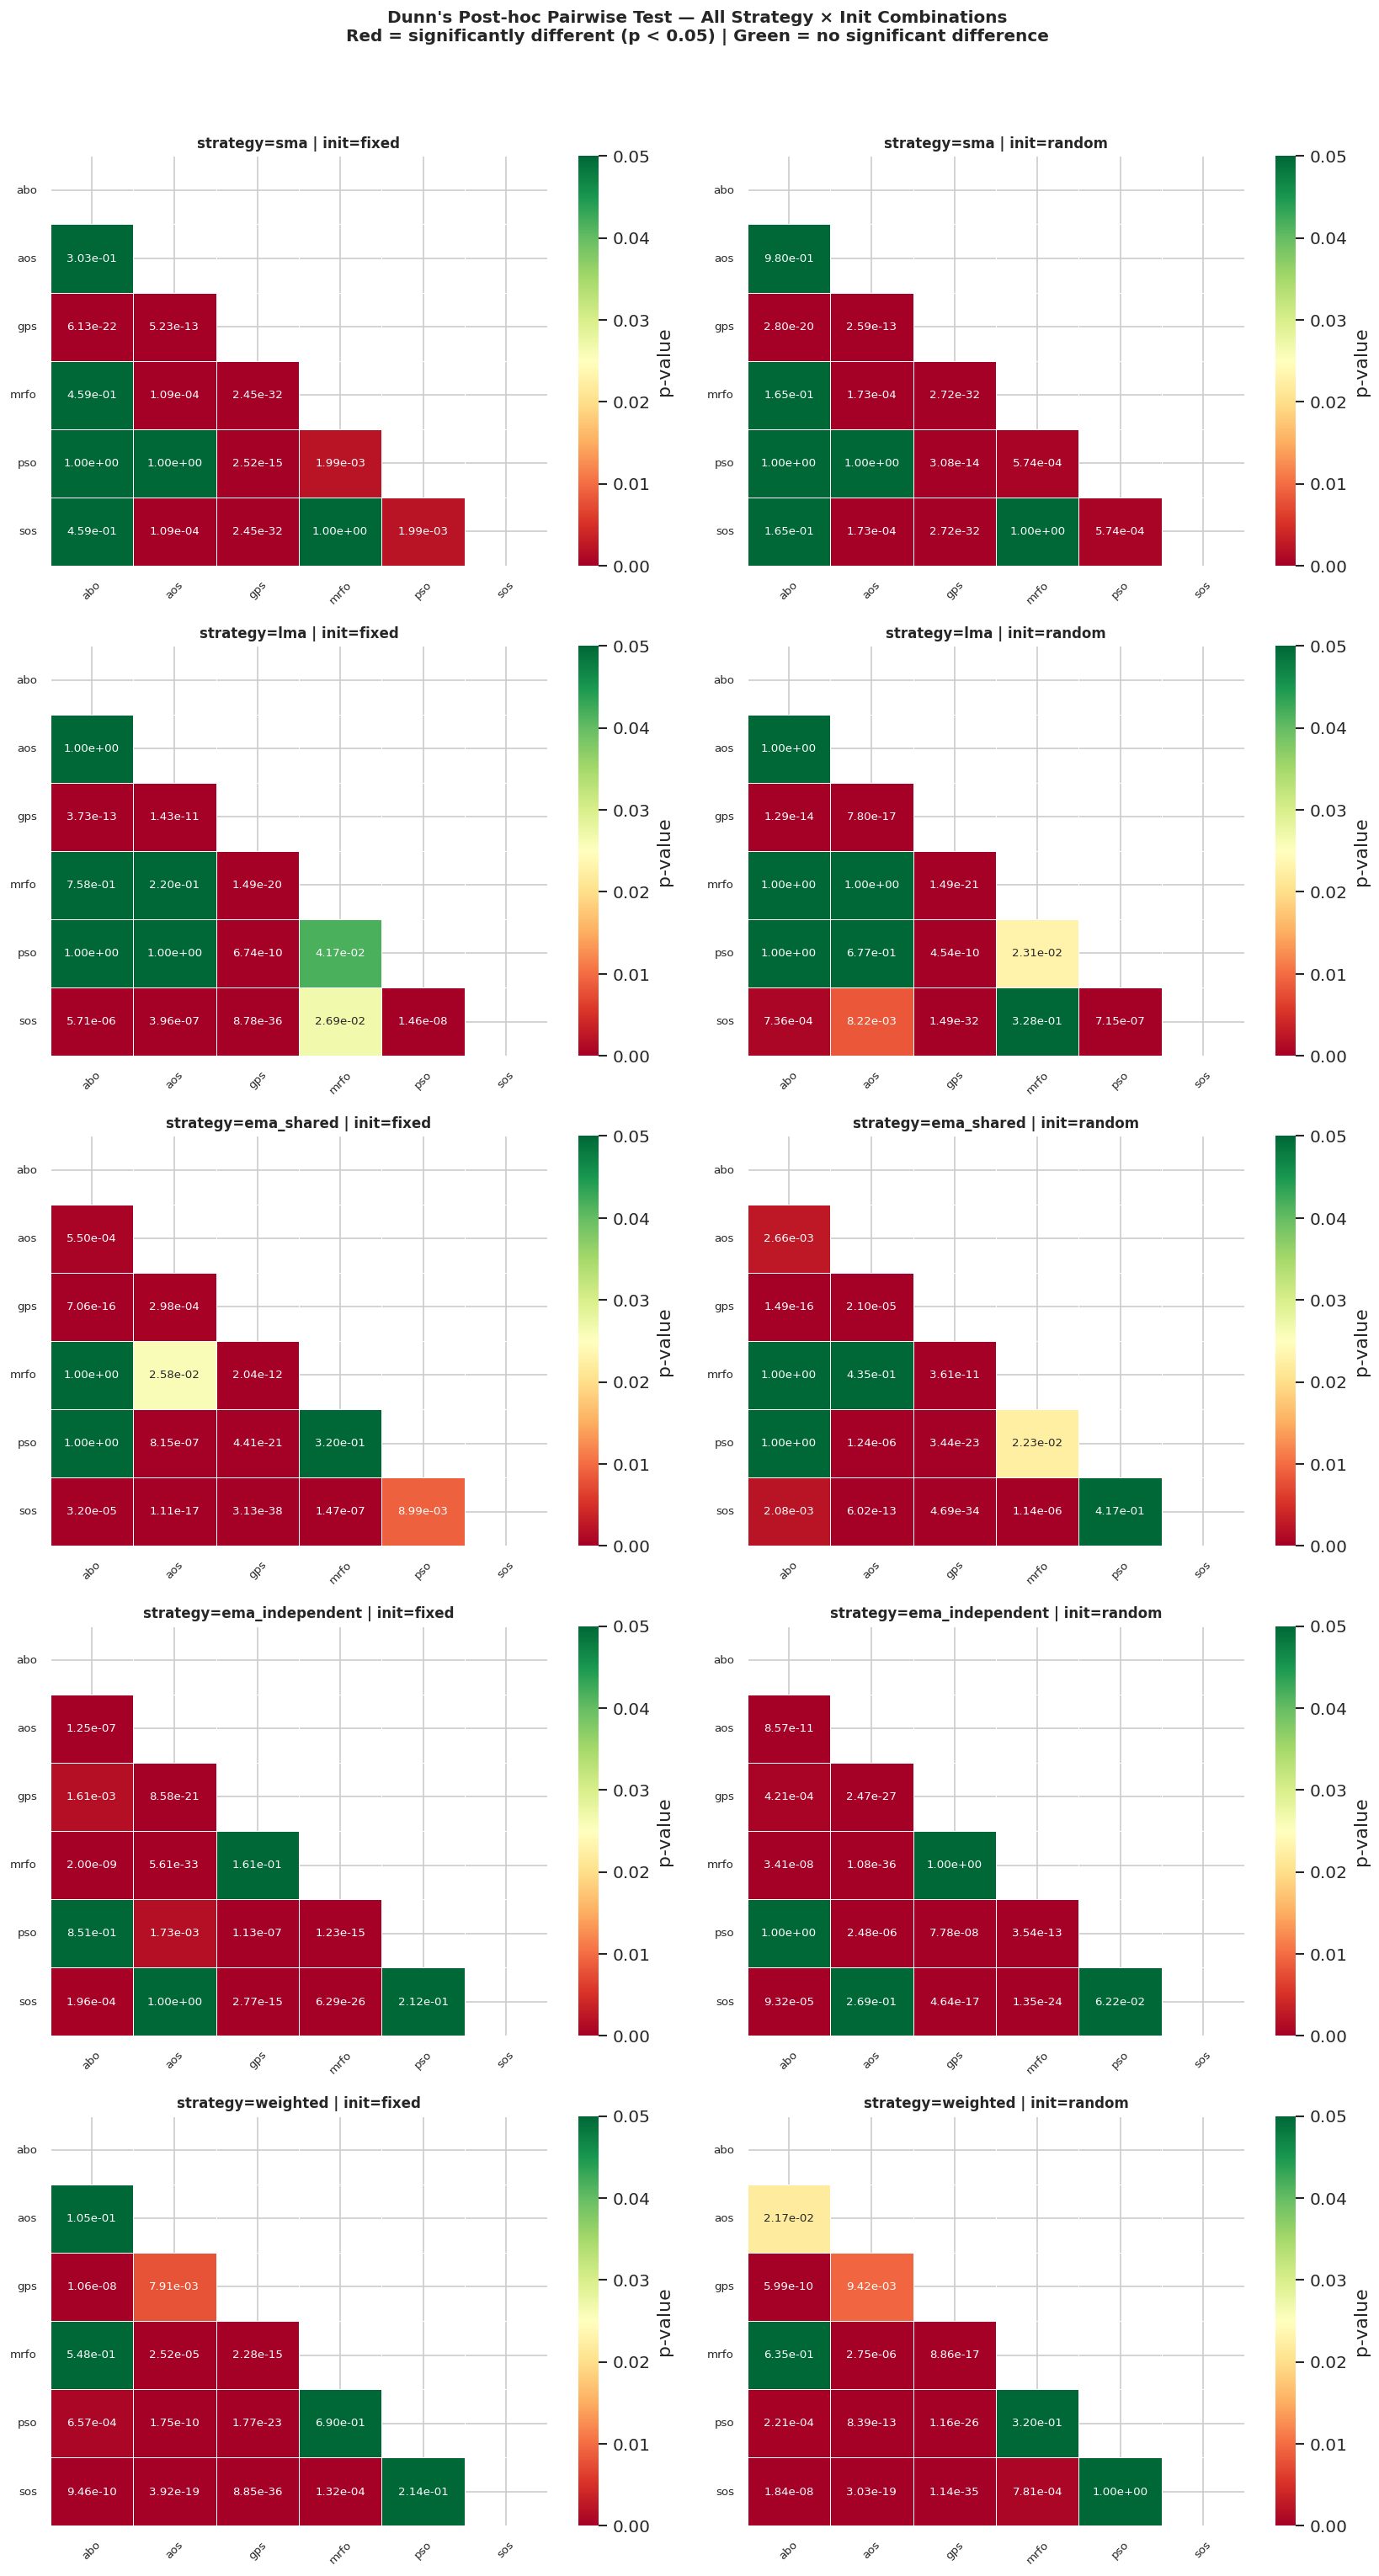

In [11]:
paired_posthoc('final_cash')

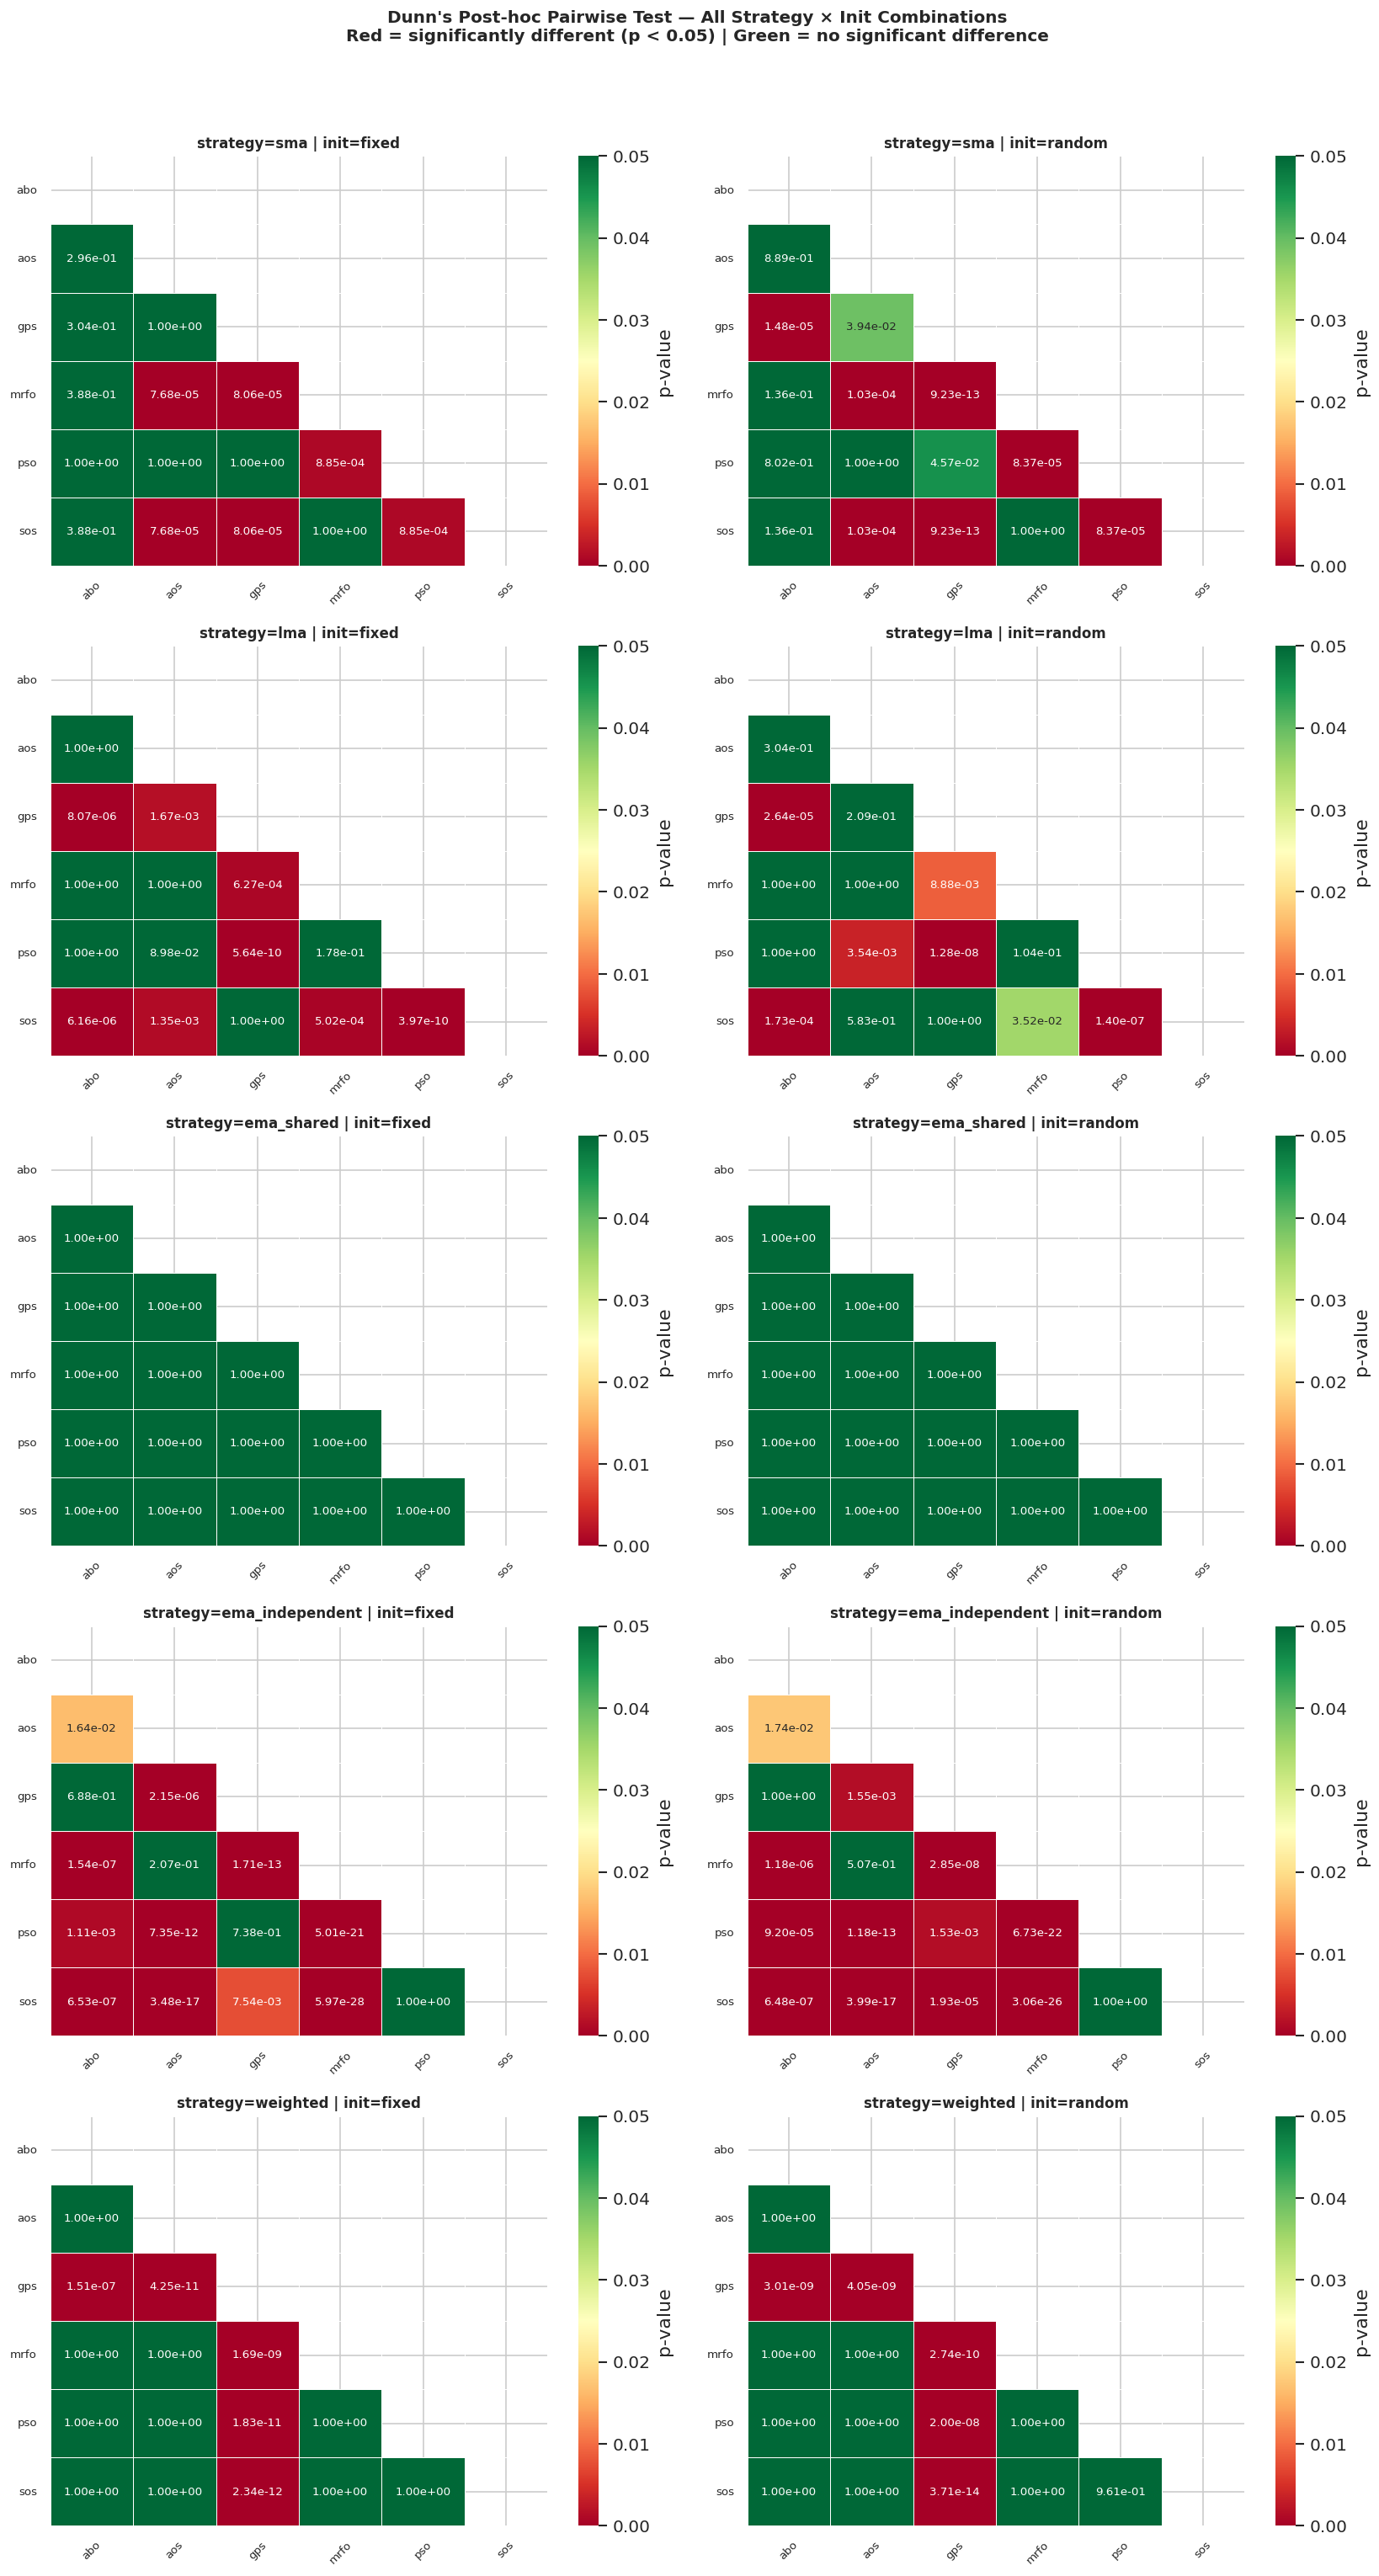

In [12]:
paired_posthoc('test_final_cash')

In [13]:
# for strategy in df['strategy'].unique():
#     for init in df['start_mode'].unique():
#         subset = df.query("strategy == @strategy and start_mode == @init")
#         medians = subset.groupby('algo')['best_fitness'].median().sort_values(ascending=False)
#         print(f"\n{strategy} | {init}")
#         display(medians)

Calculate the ratio between result medians with buy and hold benchmark

In [14]:
df['bnh_ratio'] = df['test_final_cash'] / BUY_AND_HOLD_BENCHMARK

Check how many passes the benchmark

In [15]:
passing_benchmark_df = df[df['bnh_ratio'] > 1.0].sort_values(by='bnh_ratio')

In [16]:
def check_how_many_passes(df, group_by="algo"):
    fixed_df = df[df["start_mode"] == "fixed"]
    random_df = df[df["start_mode"] == "random"]

    fixed_counts = fixed_df.groupby(group_by).size()
    random_counts = random_df.groupby(group_by).size()
    fixed_var = fixed_df.groupby(group_by)["bnh_ratio"].var()
    random_var = random_df.groupby(group_by)["bnh_ratio"].var()

    summary_df = pd.DataFrame(
        {"fixed_count": fixed_counts, "random_count": random_counts,
         "fixed_var": fixed_var, "random_var": random_var}
    )

    # Force the specific algorithms and order (fills missing with NaN)
    target = ["abo", "aos", "gps", "pso", "sos", "mrfo"] if group_by == 'algo' \
        else ['sma', 'lma', 'ema_shared', 'ema_independent', 'weighted']

    summary_df = summary_df.reindex(target)

    # Fill NaN values with 0 for counts, convert counts to integers
    summary_df[["fixed_count", "random_count"]] = summary_df[["fixed_count", "random_count"]].fillna(0).astype(int)

    # Calculate percentages (divided by 900)
    summary_df[f"% out of 900 fixed"] = (summary_df["fixed_count"] / 900) * 100
    summary_df[f"% out of 900 random"] = (summary_df["random_count"] / 900) * 100

    # Calculate percentage per trial (divided by 30)
    summary_df[f"% out of 30 fixed"] = (summary_df["fixed_count"] / 30) * 100
    summary_df[f"% out of 30 random"] = (summary_df["random_count"] / 30) * 100

    # Clean up column order for easy reading
    column_order = [
        "fixed_count",
        f"% out of 900 fixed",
        f"% out of 30 fixed",
        "fixed_var",
        "random_count",
        f"% out of 900 random",
        f"% out of 30 random",
        "random_var",
    ]

    summary_df = summary_df[column_order]
    return summary_df


display(check_how_many_passes(passing_benchmark_df, "algo").round(3))
display(check_how_many_passes(passing_benchmark_df, "strategy").round(3))

,fixed_count,% out of 900 fixed,% out of 30 fixed,fixed_var,random_count,% out of 900 random,% out of 30 random,random_var
algo,,,,,,,,
abo,4,0.444,13.333,0.008,9,1.000,30.000,0.032
aos,3,0.333,10.000,0.017,5,0.556,16.667,0.011
gps,5,0.556,16.667,0.113,3,0.333,10.000,0.016
pso,4,0.444,13.333,0.041,7,0.778,23.333,0.029
sos,8,0.889,26.667,0.057,5,0.556,16.667,0.040
mrfo,3,0.333,10.000,0.029,6,0.667,20.000,0.031


,fixed_count,% out of 900 fixed,% out of 30 fixed,fixed_var,random_count,% out of 900 random,% out of 30 random,random_var
strategy,,,,,,,,
sma,0,0.000,0.000,NaN,0,0.000,0.000,NaN
lma,0,0.000,0.000,NaN,0,0.000,0.000,NaN
ema_shared,14,1.556,46.667,0.046,20,2.222,66.667,0.050
ema_independent,2,0.222,6.667,0.000,0,0.000,0.000,NaN
weighted,11,1.222,36.667,0.001,15,1.667,50.000,0.008


In [17]:
ct = pd.crosstab(
    passing_benchmark_df['algo'],
    [passing_benchmark_df['strategy'], passing_benchmark_df['start_mode']]
)

# Add total row
ct.loc['total'] = ct.sum()

display(ct)


strategy   ema_independent ema_shared        weighted       
start_mode           fixed      fixed random    fixed random
algo                                                        
abo                      0          1      3        3      6
aos                      0          1      3        2      2
gps                      2          3      3        0      0
mrfo                     0          3      3        0      3
pso                      0          2      6        2      1
sos                      0          4      2        4      3
total                    2         14     20       11     15

# Plot the bar for test_final_cash

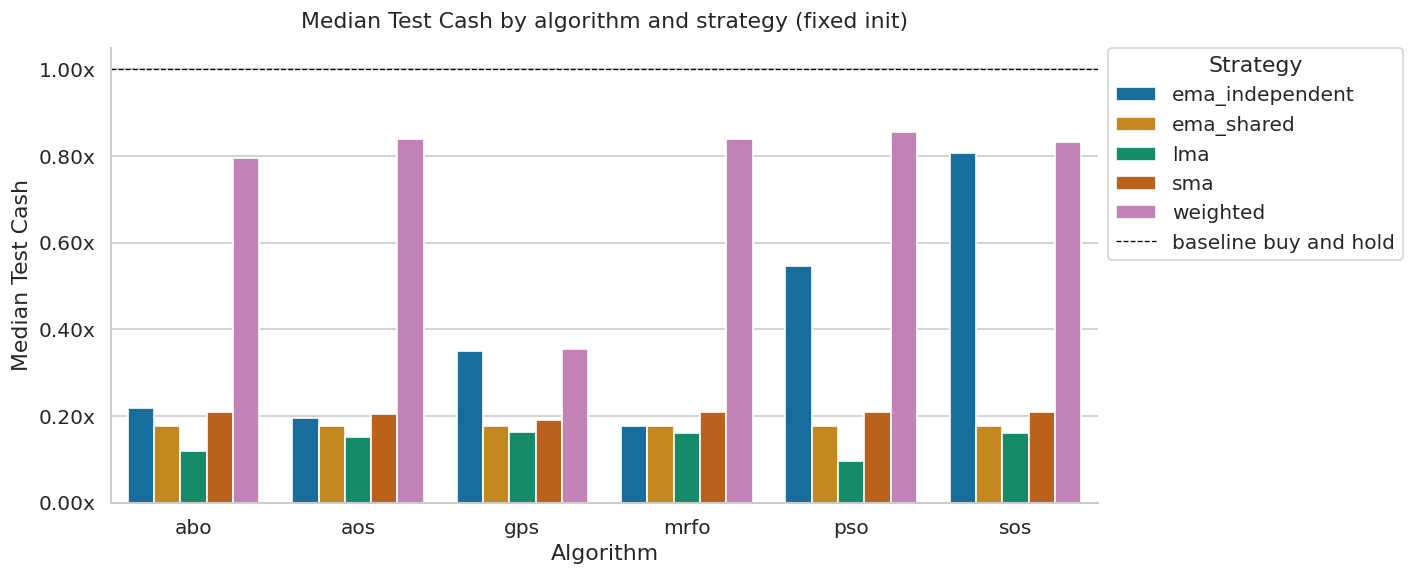

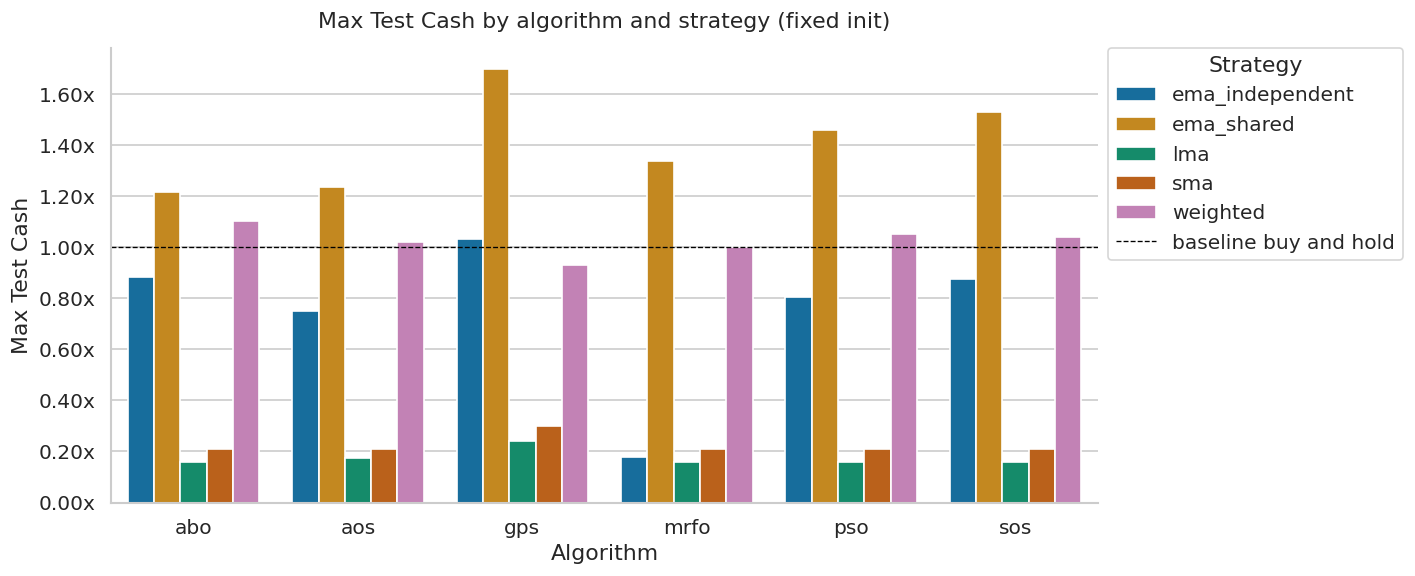

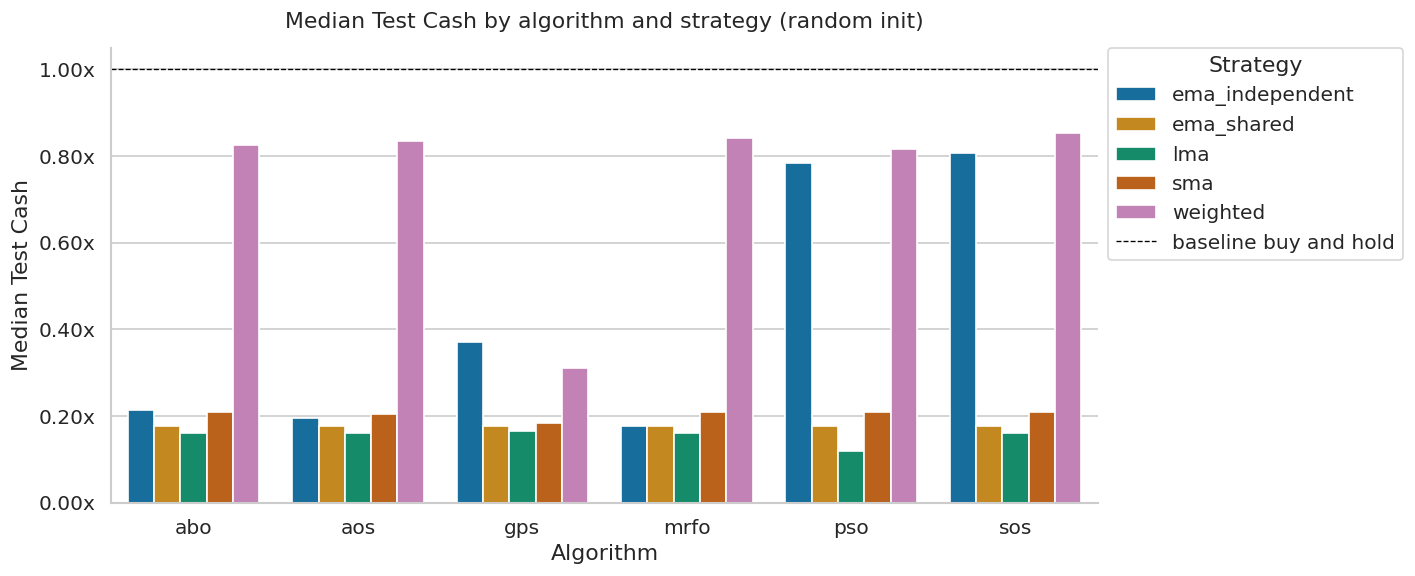

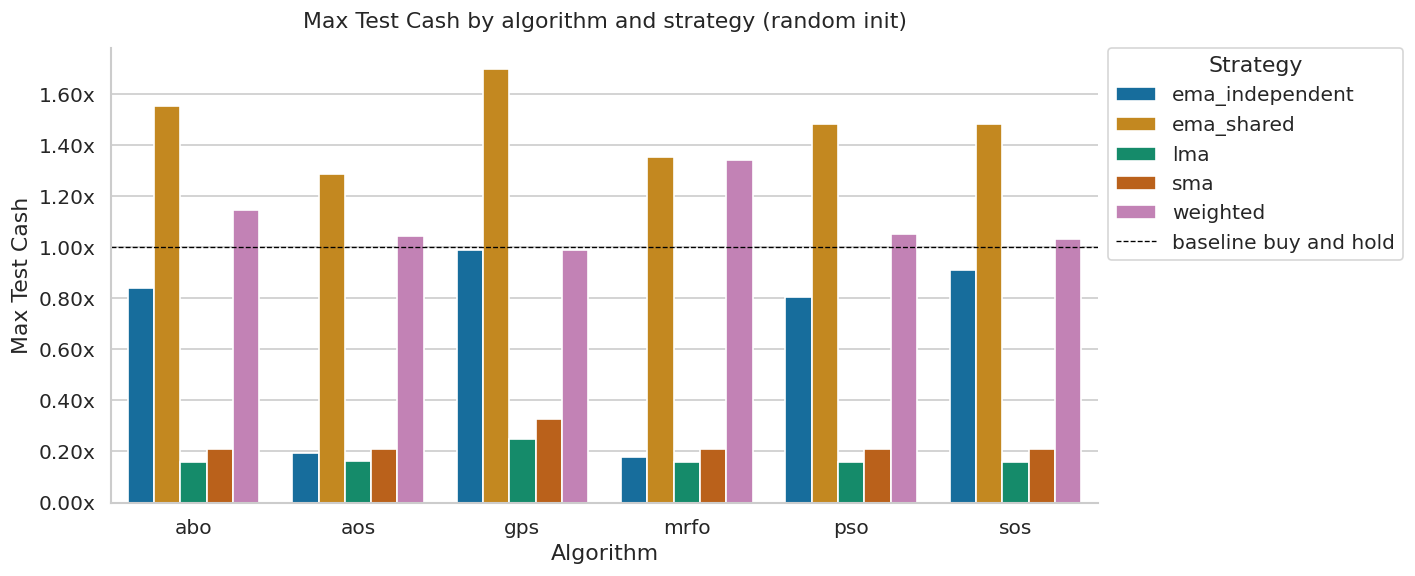

In [18]:

def plot_bar(data_points, plot_type, init_point, save_name):
    fig, ax = plt.subplots(figsize=(12, 5))

    sns.barplot(
        data=data_points,
        x='algo',
        y='bnh_ratio',
        hue='strategy',
        palette='colorblind',   # distinguishable without relying on red/green
        ax=ax
    )

    # Reference line
    ax.axhline(1, color='black', linewidth=0.8, linestyle='--', label='baseline buy and hold')

    ax.set_title(f'{plot_type} by algorithm and strategy ({init_point} init)', pad=12)
    ax.set_xlabel('Algorithm')
    ax.set_ylabel(f'{plot_type}')
    ax.legend(title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.2f}x'))

    plt.tight_layout()
    plt.savefig(f'./report/images/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def group_data(df, initial_mode='fixed', group_type='median'):
    grouped_data = (
        df[df['start_mode'] == initial_mode]
        .groupby(['algo', 'strategy'])['bnh_ratio']
        .agg(group_type)
        .reset_index()
    )
    return grouped_data

plot_bar(group_data(df, initial_mode='fixed', group_type='median'),
    plot_type='Median Test Cash', init_point='fixed', save_name='max_test_cash_random')

plot_bar(group_data(df, initial_mode='fixed', group_type='max'),
    plot_type='Max Test Cash', init_point='fixed', save_name='max_test_cash_fixed')

plot_bar(group_data(df, initial_mode='random', group_type='median'),
    plot_type='Median Test Cash', init_point='random', save_name='median_test_cash_random')
    
plot_bar(group_data(df, initial_mode='random', group_type='max'),
    plot_type='Max Test Cash', init_point='random', save_name='median_test_cash_fixed')

## Spearman ρ(train_fitness, test_fitness) per Strategy

This is pooled across both fixed and random

/tmp/ipykernel_5809/221610182.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=15, ha="right")
/tmp/ipykernel_5809/221610182.py:46: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 1
  ax.legend(handles=[ax.get_legend_handles_labels()[0][0]] + legend_items,


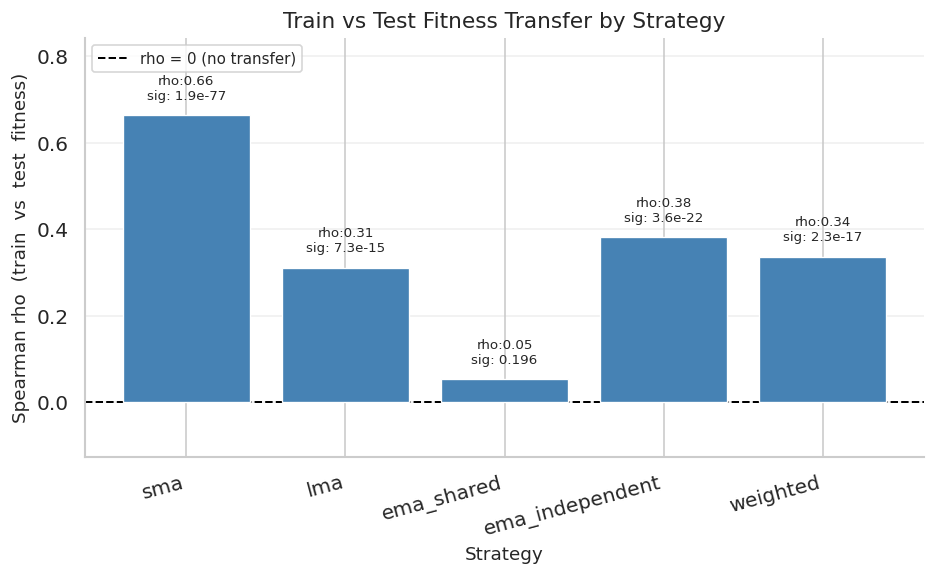

In [19]:
from scipy.stats import spearmanr

strategies = ["sma", "lma", "ema_shared", "ema_independent", "weighted"]

rhos, pvals = [], []
for s in strategies:
    sub = df[df["strategy"] == s]
    rho, p = spearmanr(sub["final_cash"], sub["test_final_cash"])
    rhos.append(rho)
    pvals.append(p)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(strategies, rhos, color="steelblue", edgecolor="white", linewidth=0.8, zorder=3)

for bar, rho, p in zip(bars, rhos, pvals):
    yoff = 0.03 if rho >= 0 else -0.06

    p_text = f"{p:.1e}" if p < 0.001 else f"{p:.3f}"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rho + yoff,
        f'rho:{round(rho, 2)}\nsig: {p_text}',
        ha="center", va="bottom", fontsize=8,
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1.2, label="rho = 0 (no transfer)", zorder=2)

ax.set_ylabel("Spearman rho  (train  vs  test  fitness)", fontsize=11)
ax.set_xlabel("Strategy", fontsize=11)
ax.set_title("Train vs Test Fitness Transfer by Strategy", fontsize=13)
ax.set_ylim(min(rhos) - 0.18, max(rhos) + 0.18)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_xticklabels(strategies, rotation=15, ha="right")

# Significance legend
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], color="none", label="*** p < 0.001"),
    Line2D([0], [0], color="none", label="**  p < 0.01"),
    Line2D([0], [0], color="none", label="*   p < 0.05"),
    Line2D([0], [0], color="none", label="ns  p ≥ 0.05"),
]
ax.legend(handles=[ax.get_legend_handles_labels()[0][0]] + legend_items,
          labels=["rho = 0 (no transfer)"],
          fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("./report/images/train_test_spearman.png", dpi=150)
plt.show()


When checking with spreadsheet, on `ema_shared` with `mrfo` on both random and fixed init there are 2 entries with 5660ish profit that got excluded from the result. Those are mrfo run 14 (fixed) and 1 (random).

Let's try visualizing the plot



In [20]:
mrfo_14 = df.query('algo == "mrfo" & strategy == "ema_shared" & run_id == 14 & start_mode == "fixed"')
mrfo_1 = df.query('algo == "mrfo" & strategy == "ema_shared" & run_id == 14 & start_mode == "random"')

from runners.mrfo.plot import plot_equity_and_purchases
from runners.mrfo.common import re_evaluate
from runners.mrfo.ema import get_signals_shared
import json

best_params_json = mrfo_1["best_params"].iloc[0]
short, long, buy_at, sell_at, equity_curve, cash = \
    re_evaluate(json.loads(best_params_json), train_prices, get_signals_shared)

sns.lineplot(mrfo_1["equity_curve"].iloc[0])

<Axes: >

In [21]:
pso_15 = df.query('algo == "pso" & strategy == "ema_shared" & run_id == 15 & start_mode == "fixed"')

from runners.pso.common import re_evaluate
from runners.pso.ema import get_signals_shared
import json

best_params_json = pso_15["best_params"].iloc[0]
short, long, buy_at, sell_at, equity_curve, cash = \
    re_evaluate(json.loads(best_params_json), train_prices, get_signals_shared)

print(buy_at)
print(sell_at)

[(314, np.float64(243.41)), (1564, np.float64(3849.25))]
[(1180, np.float64(11233.41)), (1859, np.float64(7168.36))]


# Aggregate and Save

In [22]:
# agg_funcs = ["mean", "median", "std", lambda x: x.std() / x.mean(), "min", "max"]
# agg_names  = ["mean", "median", "std", "cv", "min", "max"]

# def summarise(df, cols):
#     return (
#         df.groupby(["strategy", "algo"])[cols]
#         .agg(agg_funcs)
#         .set_axis(
#             pd.MultiIndex.from_product([cols, agg_names]),
#             axis=1,
#         )
#     )

# # Table 1 — cash performance
# print("=== Fixed — Cash ===")
# display(summarise(fixed_results, ["final_cash", "test_final_cash"]))

# print("=== Random — Cash ===")
# display(summarise(random_results, ["final_cash", "test_final_cash"]))

# # Table 2 — runtime & epochs
# print("=== Fixed — Runtime / Epochs ===")
# display(summarise(fixed_results, ["runtime_ms", "epoch_count"]))

# print("=== Random — Runtime / Epochs ===")
# display(summarise(random_results, ["runtime_ms", "epoch_count"]))

In [23]:
# summary_fixed_cash    = summarise(fixed_results,  ["final_cash", "test_final_cash"])
# summary_random_cash   = summarise(random_results, ["final_cash", "test_final_cash"])
# summary_fixed_runtime = summarise(fixed_results,  ["runtime_ms", "epoch_count"])
# summary_random_runtime = summarise(random_results, ["runtime_ms", "epoch_count"])

# summary_fixed_cash.to_csv("results/summary_fixed_cash.csv")
# summary_random_cash.to_csv("results/summary_random_cash.csv")
# summary_fixed_runtime.to_csv("results/summary_fixed_runtime.csv")
# summary_random_runtime.to_csv("results/summary_random_runtime.csv")

# print("Summaries saved to results/")